In [70]:
import os
import importlib
import numpy as np, pandas as pd, networkx as nx
import desikan_killiany_atlas as dkatlas
import utils_a3 as utils
import watts_in_adni as nwm

import utils_a1_a3 as utils_a1
import gudhi_persistence_a3 as gp_a1

import matplotlib.pyplot as plt
import lifelines
from sklearn.decomposition import PCA

PATH = os.getcwd()
BASE_DIR = utils.BASE_DIR
print(f"utils base directory: {BASE_DIR}")

utils base directory: U:\Academic\NetworkModels


In [86]:
# reload all
importlib.reload(utils); importlib.reload(nwm); importlib.reload(gp_a1)
importlib.reload(utils_a1); importlib.reload(dkatlas)

<module 'desikan_killiany_atlas' from 'U:\\Academic\\NetworkModels\\Project1\\A3\\desikan_killiany_atlas.py'>

In [84]:
params = {'ngeom_edges_in_persistence': True, 'max_persistence_dim': 2,
               'calculate_representation': True, 'bandwidth': 0.1,
               'resolution': 50, 'num_landscapes': 3,
               'representation_choice_function': 'persistence',
                'non_active': -1
               }
params['query_filter'] = "rid in [21, 31]"
adni_data_rel_path = os.path.join("resources", "adni_pet_image_analysis", "TAU", "structured_files_DXSUM_mereged_UCBERKELEY_TAU_6MM_06Mar2026", "DXSUM_mereged_UCBERKELEY_TAU_6MM_06Mar2026_suvr.csv")
graph_file_rel_path = os.path.join("resources", "base_data", "DKATLAS33_base.graphml")

In [51]:
df_adni = utils.df_rename_to_fsnames(adni_data_rel_path, type_filter="tau")
df_adni = utils.safe_filter_df(df_adni, True, type_filter="tau")
df_adni.sort_values(by = ['rid', 'scandate'], inplace = True)
df_adni = df_adni.query(params.get('query_filter'))
df_adni, feature_cols = utils.activations_cortical_regions_df(df_adni, True)
print(f"Shape of df_adni processed: {df_adni.shape}")
df_adni.head(10)

Shape of df_adni processed: (3, 175)


,loniuid,ptid,rid,scandate,qc_flag,tracer,summary_diagnosis,diagnosis,rh_lateralorbitofrontal,rh_parsorbitalis,...,lh_transversetemporal_positivity,lh_insula_positivity,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity
0,1594604,011_S_0021,21,2/2/2018,2,FTP,0,1,1.238,1.293,...,0,0,1,1,1,1,0,1,0,0
2,1596172,023_S_0031,31,4/23/2019,2,FTP,0,1,1.138,1.154,...,0,0,0,0,1,1,0,1,1,0
1,1596177,023_S_0031,31,4/24/2018,2,FTP,0,1,1.198,1.160,...,0,0,0,0,1,1,0,1,0,0


### COX

In [88]:
importlib.reload(gp_a1)

params['type_filter'] = "tau"
params['query_filter'] = None #"rid in [4214, 4216, 4224]"
results_df, graph = nwm.main_sims(params=params, adni_data_file_path=adni_data_rel_path,
                                  graph_file_path=graph_file_rel_path,
                                  np_global_seed=666, save_files=False)

Removing RID Patient Data 4216 as they have single record with no activations or TODO
Removing RID Patient Data 6054 as they have single record with no activations or TODO
Removing RID Patient Data 6085 as they have single record with no activations or TODO
Removing RID Patient Data 6116 as they have single record with no activations or TODO
Removing RID Patient Data 6144 as they have single record with no activations or TODO
Removing RID Patient Data 6386 as they have single record with no activations or TODO
Removing RID Patient Data 6408 as they have single record with no activations or TODO
Removing RID Patient Data 6429 as they have single record with no activations or TODO
Removing RID Patient Data 6550 as they have single record with no activations or TODO
Removing RID Patient Data 6597 as they have single record with no activations or TODO
Removing RID Patient Data 6822 as they have single record with no activations or TODO
Removing RID Patient Data 7006 as they have single rec

In [89]:
df_temp = results_df
front_columns = ['rid', 'loniuid', 'state', 'scandate', 'time', 'num_active_nodes']

In [90]:
# keep only realizations that have at least one row with state == 1
df_temp = df_temp[df_temp.groupby(['rid'])['state'].transform('max') == 1]
df_temp = df_temp[df_temp.groupby(['rid'])['state'].cumsum() <= 1]

In [91]:
suffix_columns = [f"{prefix}_{i}" for prefix in ['H', 'L', 'I', 'E'] for i in range(3)]
all_columns = list(df_temp.columns)

middle_columns = [col for col in all_columns if col not in front_columns + suffix_columns]
df_temp = df_temp[front_columns + middle_columns + suffix_columns]
df_temp.drop(columns=suffix_columns, inplace=False).head(10)

,rid,loniuid,state,scandate,time,num_active_nodes,active_nodes
16,112,1600753,1,8/13/2018,0,63,"[1, 4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 17, 19, ..."
26,377,1598072,1,6/5/2019,0,40,"[1, 14, 15, 17, 19, 20, 25, 26, 28, 29, 30, 31..."
40,626,1595829,1,4/12/2017,0,28,"[1, 17, 19, 25, 26, 27, 28, 29, 30, 31, 32, 34..."
41,668,1602536,1,10/19/2016,0,4,"[37, 38, 78, 79]"
44,679,1598589,1,6/27/2017,0,4,"[37, 38, 78, 79]"
55,800,1602467,1,9/15/2016,0,41,"[1, 19, 23, 25, 26, 27, 28, 29, 30, 31, 35, 36..."
57,908,1610449,1,10/21/2021,0,10,"[25, 27, 29, 37, 38, 66, 76, 78, 79, 80]"
58,925,1601080,1,3/30/2016,0,6,"[27, 37, 38, 41, 78, 79]"
61,1052,1602733,1,6/20/2017,0,28,"[1, 2, 23, 25, 27, 28, 29, 30, 35, 37, 38, 39,..."
63,1078,1598190,1,3/15/2017,0,38,"[1, 4, 7, 9, 14, 15, 17, 19, 20, 25, 27, 28, 2..."


In [92]:
df = df_temp
df.head(5)

,rid,loniuid,state,scandate,time,num_active_nodes,active_nodes,H_0,H_1,H_2,L_0,L_1,L_2,I_0,I_1,I_2,E_0,E_1,E_2
16,112,1600753,1,8/13/2018,0,63,"[1, 4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 17, 19, ...",1,1095,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
26,377,1598072,1,6/5/2019,0,40,"[1, 14, 15, 17, 19, 20, 25, 26, 28, 29, 30, 31...",1,1220,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
40,626,1595829,1,4/12/2017,0,28,"[1, 17, 19, 25, 26, 27, 28, 29, 30, 31, 32, 34...",82,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
41,668,1602536,1,10/19/2016,0,4,"[37, 38, 78, 79]",82,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
44,679,1598589,1,6/27/2017,0,4,"[37, 38, 78, 79]",1,1308,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0


In [93]:
landscape_cols = ['L_0', 'L_1', 'L_2']
image_cols = ['I_0', 'I_1', 'I_2']

n_components = 5

df_pca = df[['rid', 'time', 'state', 'E_0', 'E_1', 'E_2', 'H_0', 'H_1', 'H_2']].copy()


# --- FUNCTION TO RUN PCA AND ADD TO df_pca ---
def apply_pca_and_add(df, feature_col, prefix):
    valid_mask = df[feature_col].apply(lambda x: isinstance(x, np.ndarray) and not np.isnan(x).any())
    valid_df = df[valid_mask]
    if valid_df.empty:
        print(f"Skipping {feature_col} — no valid data.")
        return
    X = np.vstack(valid_df[feature_col].values)
    if X.shape[0] == 0:
        print(f"Skipping {feature_col} — empty after stacking.")
        return

    pca = PCA(n_components=min(n_components, X.shape[0]))
    X_pca = pca.fit_transform(X)
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.cumsum()}")

    pca_cols = [f"{prefix}_PC{i + 1}" for i in range(X_pca.shape[1])]

    temp = valid_df[['rid', 'time', 'state', 'E_0', 'E_1', 'E_2']].copy()
    temp[pca_cols] = X_pca

    global df_pca
    df_pca = df_pca.merge(temp, on=['rid', 'time', 'state', 'E_0', 'E_1', 'E_2', 'H_0', 'H_1', 'H_2'], how='left')

In [94]:

for col in landscape_cols:
    apply_pca_and_add(df, col, prefix=col)

for col in image_cols:
    apply_pca_and_add(df, col, prefix=col)

Skipping L_0 — no valid data.
Skipping L_1 — no valid data.
Skipping L_2 — no valid data.
Skipping I_0 — no valid data.
Skipping I_1 — no valid data.
Skipping I_2 — no valid data.


In [95]:
landscape_cols = [col for col in df_pca.columns if col.startswith("L_") or col.startswith("I_") or col.startswith("E_")]

df_pca[landscape_cols] = df_pca[landscape_cols].applymap(
    lambda x: np.zeros_like(x) if isinstance(x, float) and np.isnan(x) else x
)
df_pca = df_pca.sort_values(["rid", "time"])

df_pca["start"] = df_pca["time"]
df_pca["stop"] = df_pca.groupby(["rid"])["time"].shift(-1)
df_pca["stop"] = df_pca["stop"].fillna(df_pca["start"] + 1)

landscape_cols = sorted([col for col in df_pca.columns if col.startswith("L_")])
image_cols = sorted([col for col in df_pca.columns if col.startswith("I_")])
essentials_cols = sorted([col for col in df_pca.columns if col.startswith("E_")])

ordered_cols = ["id", "start", "stop", "state", 'H_0', 'H_1', 'H_2'] + landscape_cols + image_cols + essentials_cols
df_pca['id'] = df['rid'].astype(str)  # + "_" + df['realization_id'].astype(str) # + df['time'].astype(str)

df_pca = df_pca[ordered_cols]
df_pca.drop(columns=['E_0', 'E_1', 'E_2', 'H_2', 'H_0'], inplace=True)
df_pca.head(10)

C:\Users\sranasin\AppData\Local\Temp\ipykernel_9172\3263031159.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_pca[landscape_cols] = df_pca[landscape_cols].applymap(


,id,start,stop,state,H_1
16,112,0,1.0,1,1095
26,377,0,1.0,1,1220
40,626,0,1.0,1,0
41,668,0,1.0,1,0
44,679,0,1.0,1,1308
55,800,0,1.0,1,0
57,908,0,1.0,1,0
58,925,0,1.0,1,0
61,1052,0,1.0,1,967
63,1078,0,1.0,1,0


In [96]:
from lifelines import CoxTimeVaryingFitter
ctv = CoxTimeVaryingFitter()
ctv.fit(df_pca, id_col="id", start_col="start", stop_col="stop", event_col="state")
ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 447 periods, 447 subjects, 447 events>
         event col = 'state'
number of subjects = 447
 number of periods = 447
  number of events = 447
partial log-likelihood = -2284.81
  time fit was run = 2026-03-08 01:19:47 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
H_1        0.00      1.00      0.00           -0.00            0.00                1.00                1.00

           cmp to    z    p  -log2(p)
covariate                            
H_1          0.00 0.00 1.00     -0.00
---
Partial AIC = 4571.63
log-likelihood ratio test = 0.00 on 1 df
-log2(p) of ll-ratio test = -0.00

<Axes: xlabel='log(HR) (95% CI)'>

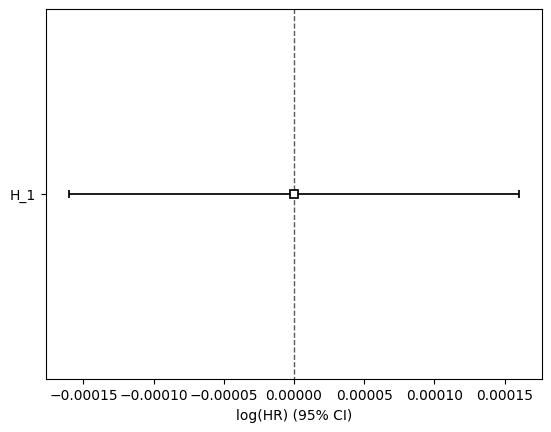

In [97]:
ctv.plot()